<hr style="border:2px solid #2196F3;">

## 🧑‍💻 Lecture 07 - Supervised Learning Models

<hr style="border:2px solid #2196F3;">

## <b>🎯Logistic Regression</b>

In [1]:
import statsmodels.api as sm
import pandas as pd

# loading the training dataset
df = pd.read_csv('Default.csv')

df.head()
# remark: take note the encoding in the data set
# student: 1; non-student: 0
# default: 1; non-default: 0

,default,student,loan,income
0,0,0,730,44362
1,0,1,817,12106
2,0,0,1074,31767
3,0,0,529,35704
4,0,0,786,38463


In [2]:
import statsmodels.api as sm
import pandas as pd

# defining the dependent and independent variables
x = df[['loan']]
y = df[['default']]

# Add a constant term beta_0 to the predictor variable
x1 = sm.add_constant(x)

model = sm.Logit(y, x1)

# building the model and fitting the data
log_reg = model.fit()

# printing the summary table
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.081399
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4998
Method:                           MLE   Df Model:                            1
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                  0.4635
Time:                        15:02:55   Log-Likelihood:                -407.00
converged:                       True   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                6.177e-155
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6591      0.502    -21.246      0.000     -11.642      -9.676
loan           0.0056      0

### ------ The fitted logistic regression model can be written as ------

$$
log(\frac{p(X)}{1-p(X)}) = -10.6591 + 0.0056X_{loan} + \epsilon
$$

                            OLS Regression Results                            
Dep. Variable:                default   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     743.7
Date:                Fri, 04 Sep 2026   Prob (F-statistic):          8.71e-153
Time:                        15:03:01   Log-Likelihood:                 1722.2
No. Observations:                5000   AIC:                            -3440.
Df Residuals:                    4998   BIC:                            -3427.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0784      0.005    -16.284      0.0

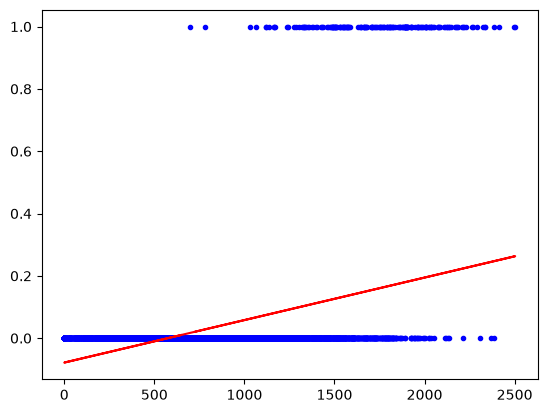

In [3]:
import matplotlib.pyplot as plt

# simple linear regression
x = df['loan']
y = df['default']

x1 = sm.add_constant(x)

model = sm.OLS(y, x1)
results = model.fit()
print(results.summary())

# plot the fitting results
plt.plot(x, y, 'b.') #blue
plt.plot(x, results.predict(x1), 'r') #red
plt.show()

###  ------ The fitted linear regression model can be written as ------
$$
y = -0.0784 + 0.0001X_{loan} + \epsilon
$$

### Multiple Logistic Regression

In [4]:
# defining the dependent and independent variables
Xtrain = df[['student', 'loan']]
ytrain = df[['default']]

# Add a constant term beta_0 to the predictor variable
Xtrain_1 = sm.add_constant(Xtrain)

model = sm.Logit(ytrain, Xtrain_1)

# building the model and fitting the data
log_reg = model.fit()

# printing the summary table
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.079684
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4997
Method:                           MLE   Df Model:                            2
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                  0.4748
Time:                        15:03:02   Log-Likelihood:                -398.42
converged:                       True   LL-Null:                       -758.57
Covariance Type:            nonrobust   LLR p-value:                3.870e-157
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.8525      0.519    -20.921      0.000     -11.869      -9.836
student       -0.8402      0

### ------ The fitted logistic regression model can be written as ------

$$
log(\frac{p(X)}{1-p(X)}) = -10.8525 - 0.8402X_{student} + 0.0059X_{loan} + \epsilon
$$

## <b>🎯Confusion Matrix</b>

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

<h3 style="color:#E64C17">Data set: Default.csv</h3>
<p>The data set contains the profile information of 5,000 clients, as well as their default status (yes or no) in repayment of bank loans in the historical record. The case study tries to predict the chance of default for a new client who is applying for the bank loan. </p>

In [6]:
# The loan default data set
df = pd.read_csv('Default.csv')
df.head()

,default,student,loan,income
0,0,0,730,44362
1,0,1,817,12106
2,0,0,1074,31767
3,0,0,529,35704
4,0,0,786,38463


In [7]:
# defining the dependent and independent variables
X = df[['student', 'loan', 'income']]
y = df['default']
X.shape, y.shape

((5000, 3), (5000,))

<h3 style="color:#E64C17">Confusion Matrix</h3>

In [8]:
# Add a constant term beta_0 to the predictor variable
X_temp = sm.add_constant(X)

model = sm.Logit(y, X_temp)

# building the model and fitting the data
log_reg = model.fit()

# printing the summary table
# print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.079505
         Iterations 10


In [9]:
# predicted prob of default based on the logistic reg model
y_pred = log_reg.predict()
print(y_pred)

# here we can set a threshold value alpha
# if prob of default < alpha, it is predicted as 'non-default'
# if prob of default >= alpha, it is predicted as 'default'
alpha = 0.5

for i in range(len(y_pred)):
    if y_pred[i] < alpha:
        y_pred[i] = 0
    else:
        y_pred[i] = 1

print(y_pred)

[1.52367621e-03 9.47777556e-04 9.43982696e-03 ... 7.45878043e-01
 4.68859287e-03 7.33891211e-04]
[0. 0. 0. ... 1. 0. 0.]


In [10]:
from sklearn.metrics import confusion_matrix
y_true = y

print(confusion_matrix(y_true, y_pred))

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
print("tn, fp, fn, tp:", tn, fp, fn, tp)

[[4803   22]
 [ 113   62]]
tn, fp, fn, tp: 4803 22 113 62


<h3 style="color:#E64C17">Case Study: Classification of growth and value stock using KNN method</h3>

<h3 style="color:blue">Problem description</h3>

<p>Value stocks present an opportunity to buy shares below their actual value. The value stocks are those which the investors believe are currently undervalued and being traded in a price lower than its real value. Value stocks are publicly traded companies trading for relatively cheap valuations relative to their earnings and long-term growth potential. They are expected to give great return in future. </p>

<p> Growth stocks exhibit above-average revenue and earnings growth potential. Growth stocks are those which are predicted to outperform the overall market or a subset of the market in the future for a period of time due to their potentials. Growth companies prioritize going from small, up-and-coming businesses to leaders in their respective industries as quickly as possible.</p>

In [1]:
# the given data set X = (x_1, x_2), Y = 0 or 1 (Growth or Value stock)
X = [[1.1, 3], [2.1, 1], [3.8, 1], [2.5, 2], [5, 2], [5, 6], [4.2, 7], [1.8, 3], [3, 5], [4, 5]]
Y = [1, 1, 0, 1, 0, 0, 0, 1, 0, 1]

In [2]:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
from sklearn.neighbors import KNeighborsClassifier 

# the number of nearest neighbours
k = 3
knn_model = KNeighborsClassifier(n_neighbors=k).fit(X, Y)

In [3]:
# predict the y value for a new input X = (0, 2)
predicted = knn_model.predict([[0, 2]])
print(predicted)

[1]


In [4]:
# if you are running this code the first time, you need to install the package named 'mglearn'
# Once installed successfully, you do not need to run this every time
!pip install mglearn

   ---------------------------------------- 0.0/581.4 kB ? eta -:--:--
   ---------------------------------------- 581.4/581.4 kB 6.8 MB/s eta 0:00:00


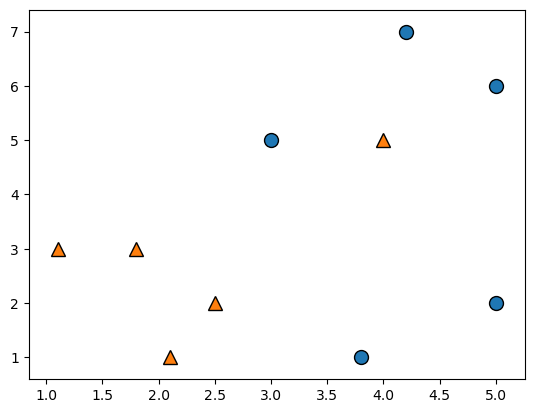

In [5]:
# this package is used to help draw the plot we want
import mglearn
import numpy as np

mglearn.discrete_scatter(np.array(X)[:, 0], np.array(X)[:, 1], Y)

Text(0.5, 1.0, 'K=5')

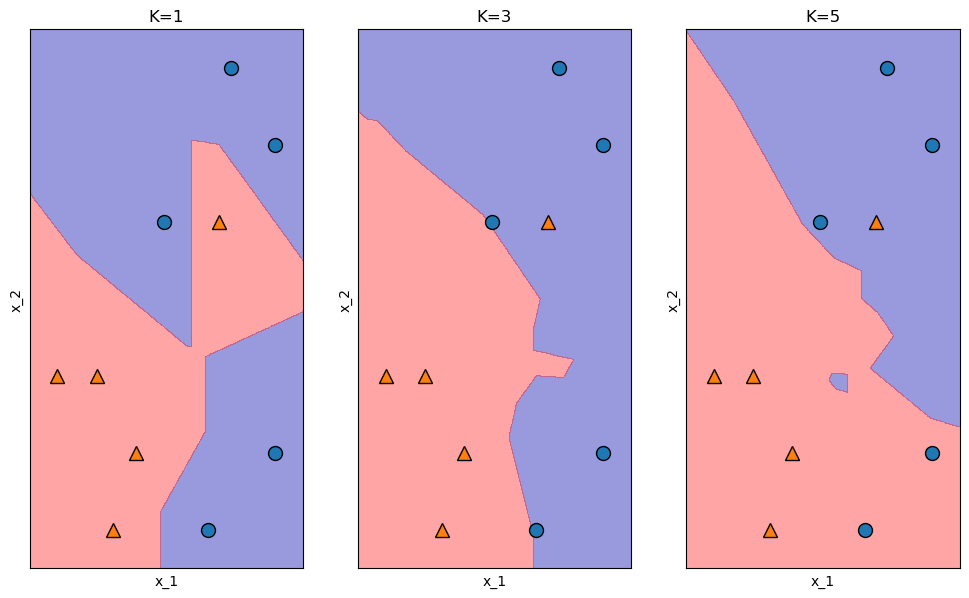

In [6]:
import matplotlib.pyplot as plt
# create subplots with 1 row, 3 columns
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 7))

# the 1st subplot ax1
# k = 1
knn_model = KNeighborsClassifier(n_neighbors=1).fit(X, Y)
mglearn.plots.plot_2d_separator(knn_model, np.array(X), fill=True, eps=0.5, alpha=0.4, ax=ax1)
mglearn.discrete_scatter(np.array(X)[:, 0], np.array(X)[:, 1], Y, ax=ax1)
ax1.set_xlabel('x_1')
ax1.set_ylabel('x_2')
ax1.set_title('K=1')

# the 2nd subplot ax2
# k = 3
knn_model = KNeighborsClassifier(n_neighbors=3).fit(X, Y)
mglearn.plots.plot_2d_separator(knn_model, np.array(X), fill=True, eps=0.5, alpha=0.4, ax=ax2)
mglearn.discrete_scatter(np.array(X)[:, 0], np.array(X)[:, 1], Y, ax=ax2)
ax2.set_xlabel('x_1')
ax2.set_ylabel('x_2')
ax2.set_title('K=3')

# the 3rd subplot ax3
# k = 5
knn_model = KNeighborsClassifier(n_neighbors=5).fit(X, Y)
mglearn.plots.plot_2d_separator(knn_model, np.array(X), fill=True, eps=0.5, alpha=0.4, ax=ax3)
mglearn.discrete_scatter(np.array(X)[:, 0], np.array(X)[:, 1], Y, ax=ax3)
ax3.set_xlabel('x_1')
ax3.set_ylabel('x_2')
ax3.set_title('K=5')

# Reference
# Source codes: https://github.com/amueller/mglearn/blob/master/mglearn/plot_2d_separator.py

<h3 style="color:#E64C17">Decision Tree</h3>

In [1]:
import pandas as pd
import numpy as np

data_hitters = pd.read_csv("Hitters.csv")
data_hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [3]:
# remove the missing values in 'Salary'
print(data_hitters.isnull().sum())
df = data_hitters.dropna(axis=0)
df = df[['Hits', 'Years', 'Salary']]

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64


In [5]:
# compute the logarithm of the 'Salary' value
log_df = df.copy()
log_df['Salary'] = np.log(df['Salary'])
log_df.head()

,Hits,Years,Salary
1,81,14,6.163315
2,130,3,6.173786
3,141,11,6.214608
4,87,2,4.516339
5,169,11,6.620073


In [7]:
# Fit a decision tree
# prepare the data
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

print(log_df.head())

X = log_df[["Hits", "Years"]]
y = log_df["Salary"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
# print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

   Hits  Years    Salary
1    81     14  6.163315
2   130      3  6.173786
3   141     11  6.214608
4    87      2  4.516339
5   169     11  6.620073


In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

reg_dt = DecisionTreeRegressor(max_leaf_nodes=3, random_state=0)
reg_dt.fit(X, y)

text_representation = tree.export_text(reg_dt, feature_names=["Hits", "Years"])
print(text_representation)

|--- Years <= 4.50
|   |--- value: [5.11]
|--- Years >  4.50
|   |--- Hits <= 117.50
|   |   |--- value: [6.00]
|   |--- Hits >  117.50
|   |   |--- value: [6.74]



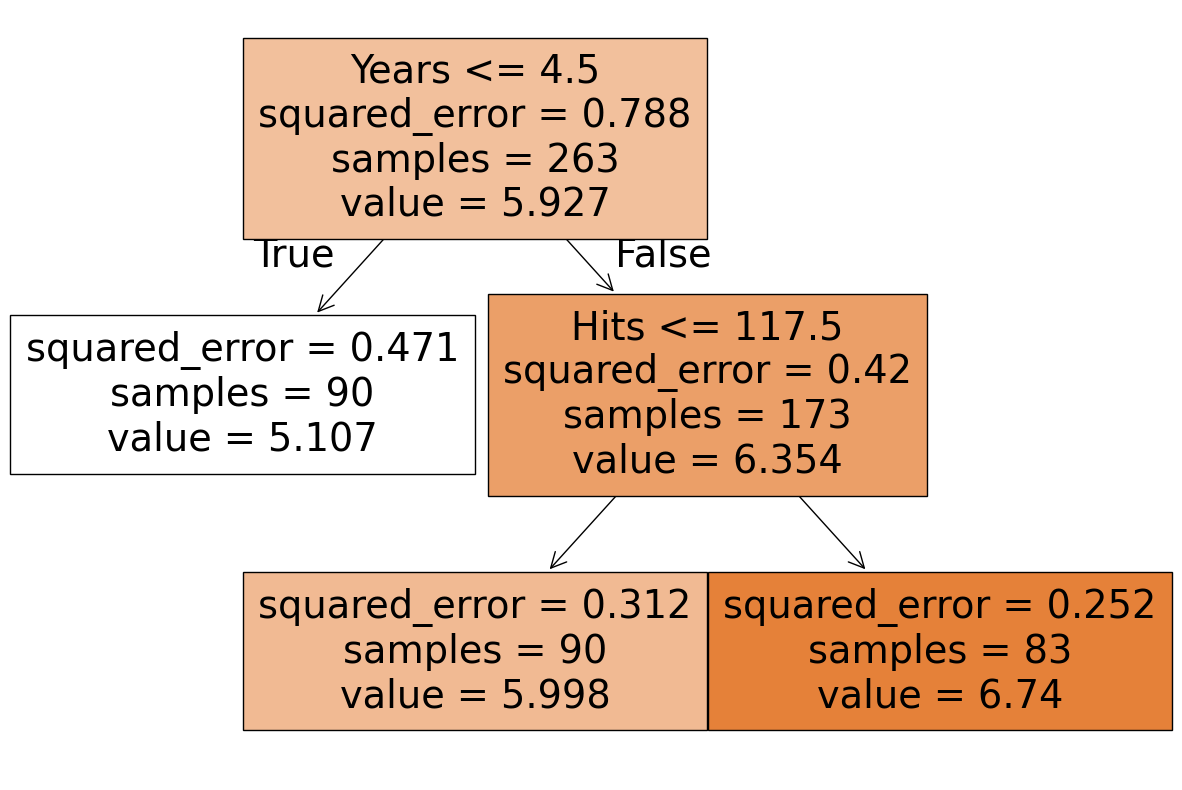

In [15]:
fig = plt.figure(figsize=(15,10))
reg_tree = tree.plot_tree(reg_dt, feature_names=["Hits", "Years"], filled=True)